# Time Series Introduction
This notebook is a very (very) simple introduction to time series analysis. It will not go into any details on things like stationarity, exponential smoothing, ARIMA, VAR or other time series approaches. 

All these details will remain relatively simple with a nice example. In fact, an example that highlights the key limitations of time series analysis within econometrics. This example will explore a "static" time series model to determine the relationship between different variables at the same time. 

This actually means we won't be capturing any dynamics beause we will be looking at the same place $i$ at the same point in time $t \in 1,2,...T$. 

Our little example will follow the implementation of an increase excise tax on tabacoo during 1989 in California. We will follow the sales of cigarettes per capita as well as the price to determine the price elasticity of cigarettes, as well as estimate the effect of the increase excise on cigarette sales. 


In 1989, proposition 99 was enacted that increased the excise tax on cigarettes by 25 cents per pack in California. In theory, this increase in cost should decrease the number of cigarettes consumed. Let's have a look at the time series for cigarette sales to get a bit of an idea how how they've evolved.

In [148]:
%reset -f

In [149]:
import numpy             as np
import statsmodels.api   as sm
import pandas            as pd
import matplotlib.pyplot as plt
import seaborn           as sns

# setting the figure size for seaborn ploits
sns.mpl.rc('figure',figsize=(16, 8))

In [150]:
# Load in the data
df = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

# filter for california
df = df[df['california'] == True]

# add binary variable for excise tax intro
df['excise_tax_intro'] = np.where(df['after_treatment'] == True,1,0)

df = df[['year', 'cigsale','retprice','excise_tax_intro']]

# create log variables for elasticity estimates:
for x in ['cigsale','retprice']:
    df[f"ln_{x}"] = np.log(df[x])

# print info
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 62 to 92
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
dtypes: float64(4), int64(2)
memory usage: 1.7 KB


After loading in all that data, we can see that there has been a general downward trend in cigarette sales per capita since the early 1970's. 

At a glance, it does kind of seem that decrease did speed up a bit after the excise tax was introduced (dotted black line). However, not by that much if at all. 

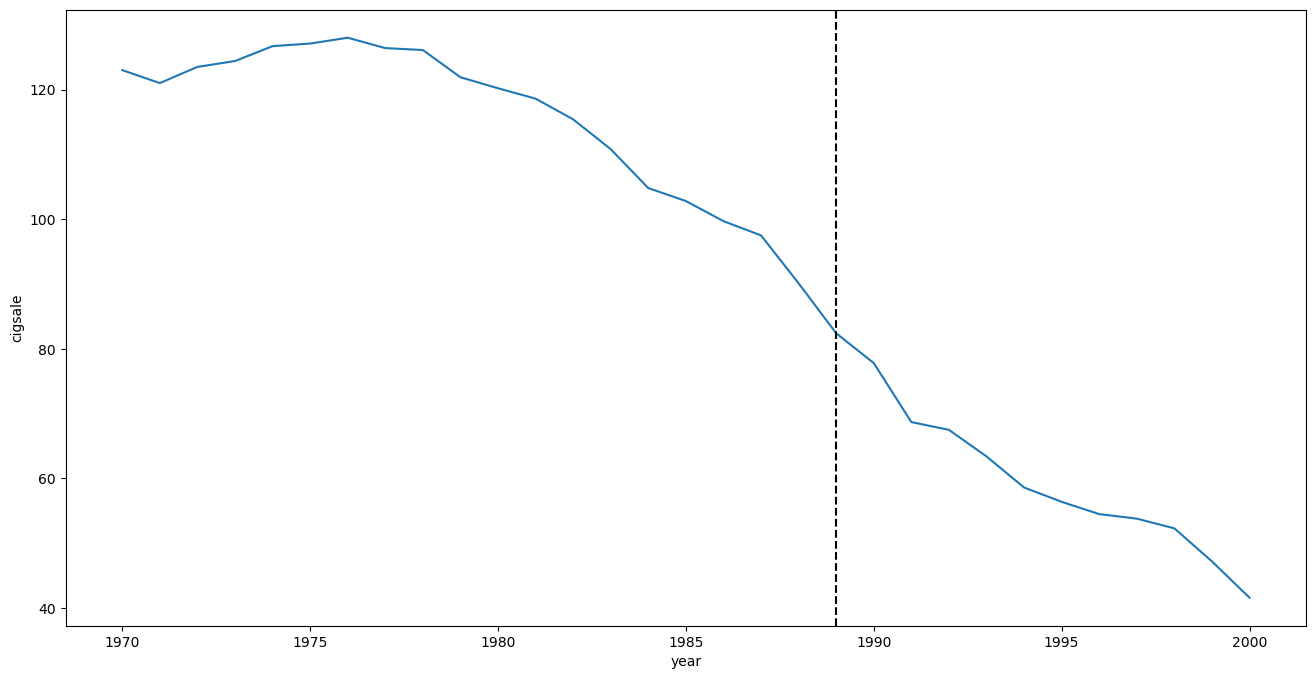

In [151]:
sns.lineplot(y = 'cigsale',
            x = 'year', 
            data = df)
plt.axvline(x = 1989, color = "black", linestyle = "--")

What we can do with a static time series model is estimate contemporaneous effects such as the price elasticity of cigarette sales.

In [152]:
print(sm.OLS(np.log(df['cigsale']), sm.add_constant(df[['excise_tax_intro', "ln_retprice"]])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.933
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                     193.4
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           4.07e-17
Time:                        17:51:14   Log-Likelihood:                 29.830
No. Observations:                  31   AIC:                            -53.66
Df Residuals:                      28   BIC:                            -49.36
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                6.1543      0.224  

We can see that there is an inelastic good, because $| \beta_{ln_retprice} | < 1$. For every 1% increase in the retail price of cigarettes, we can expect cigarette sales to decrease by 0.34% (well below a 1-to-1 decrease). 

Also of interest is the `excise_tax_intro` dummy variable that suggests the introduce of the excise tax saw an approximately 27% decrease in cigarette sales (quite a large effect). 

The adjusted $R^2$ also suggests that this model is quite a good fit. Let's have a look at how it compares to the time series. 

In [153]:
df['simple_mod_pred'] = sm.OLS(df['cigsale'], 
                               sm.add_constant(df[['excise_tax_intro',
                                                   "ln_retprice"]])).fit().predict()

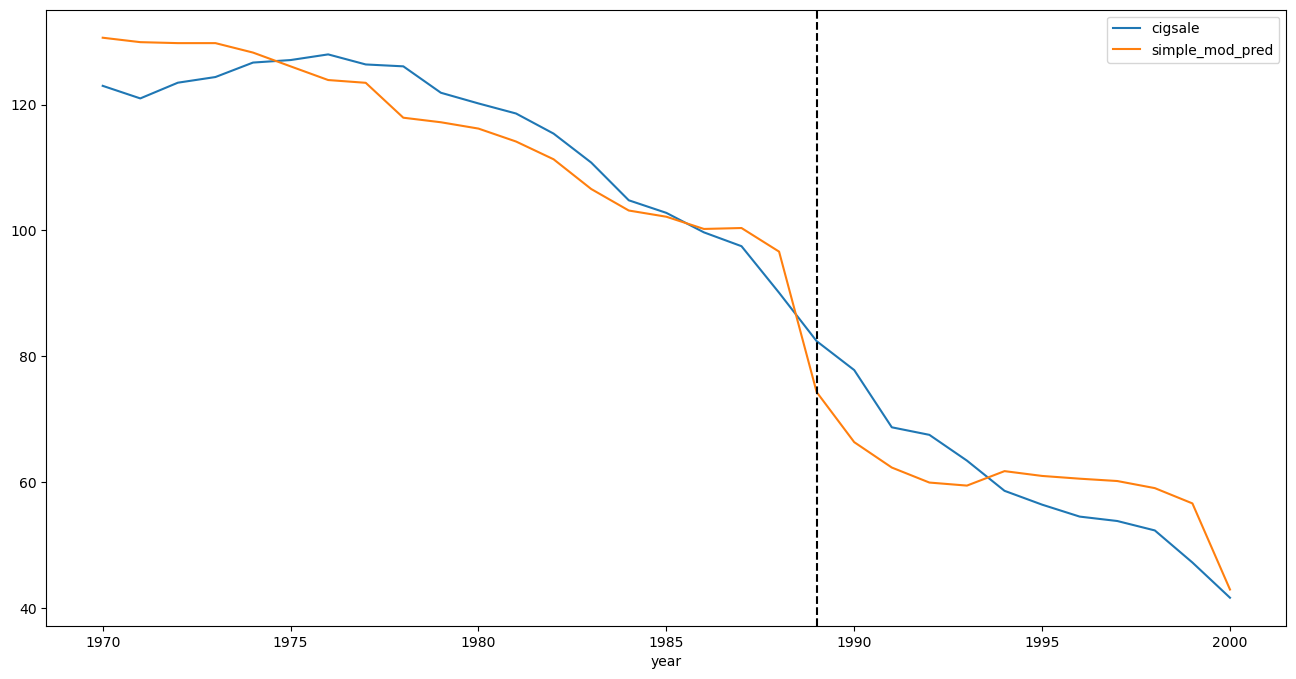

In [154]:
df.set_index("year")[['cigsale','simple_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

It's not to bad of a fit at all. However, there is some deviations and especially after the tax was introduced. If we plot the predictions against the actuals we can see that it is not a straight line.

<AxesSubplot: xlabel='cigsale', ylabel='simple_mod_pred'>

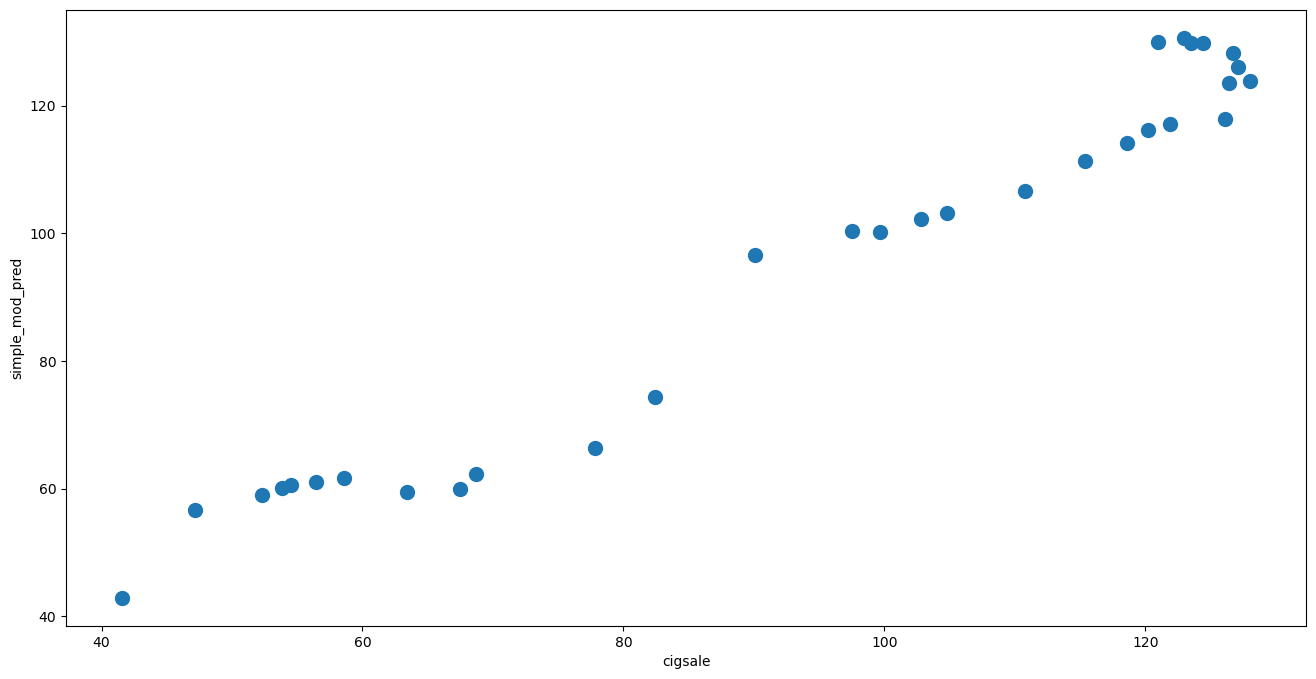

In [155]:
df.plot.scatter(x = 'cigsale', y = 'simple_mod_pred', s=100)

This simple model shows a really big decrease in cigeratte consumption per capita. However, we can make things a bit more complex by adding some year dummy variables for the post excise tax period (I am avoiding the pre excise tax period due to their being limited observations). 

If we add dummy variables for each year, we can use these as covariates in the model to hopefully improve our models predictions. 

In [156]:
df =  pd.concat([df,pd.get_dummies(df['year']).astype(int)], axis = 1)

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 62 to 92
Data columns (total 38 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
 6   simple_mod_pred   31 non-null     float64
 7   1970              31 non-null     int64  
 8   1971              31 non-null     int64  
 9   1972              31 non-null     int64  
 10  1973              31 non-null     int64  
 11  1974              31 non-null     int64  
 12  1975              31 non-null     int64  
 13  1976              31 non-null     int64  
 14  1977              31 non-null     int64  
 15  1978              31 non-null     int64  
 16  1979              31 non-null     int64  
 17  198

In [157]:
print(sm.OLS(np.log(df['cigsale']), 
             sm.add_constant(df[['excise_tax_intro', 
                                 "ln_retprice"] + df.columns[25:38].tolist()])).fit().summary())

                            OLS Regression Results                            
Dep. Variable:                cigsale   R-squared:                       0.993
Model:                            OLS   Adj. R-squared:                  0.987
Method:                 Least Squares   F-statistic:                     166.0
Date:                Tue, 23 Jun 2026   Prob (F-statistic):           1.38e-14
Time:                        17:51:15   Log-Likelihood:                 65.321
No. Observations:                  31   AIC:                            -100.6
Df Residuals:                      16   BIC:                            -79.13
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const                5.6737      0.113  

After adding all of the annual dummy variables, the effect has increased to a 38% decrease. The price elasticity of cigarettes has actually increased for -0.22% for every 1% increase in the retail price of cigarettes (still an inelastic good. 

The adjusted $R^2$ is now basically perfect (this could be a problem), so let's see how the predictions have improved.

In [158]:
df['complex_mod_pred'] =  sm.OLS(df['cigsale'], sm.add_constant(df[['excise_tax_intro', "ln_retprice"] + df.columns[25:38].tolist()])).fit().predict()

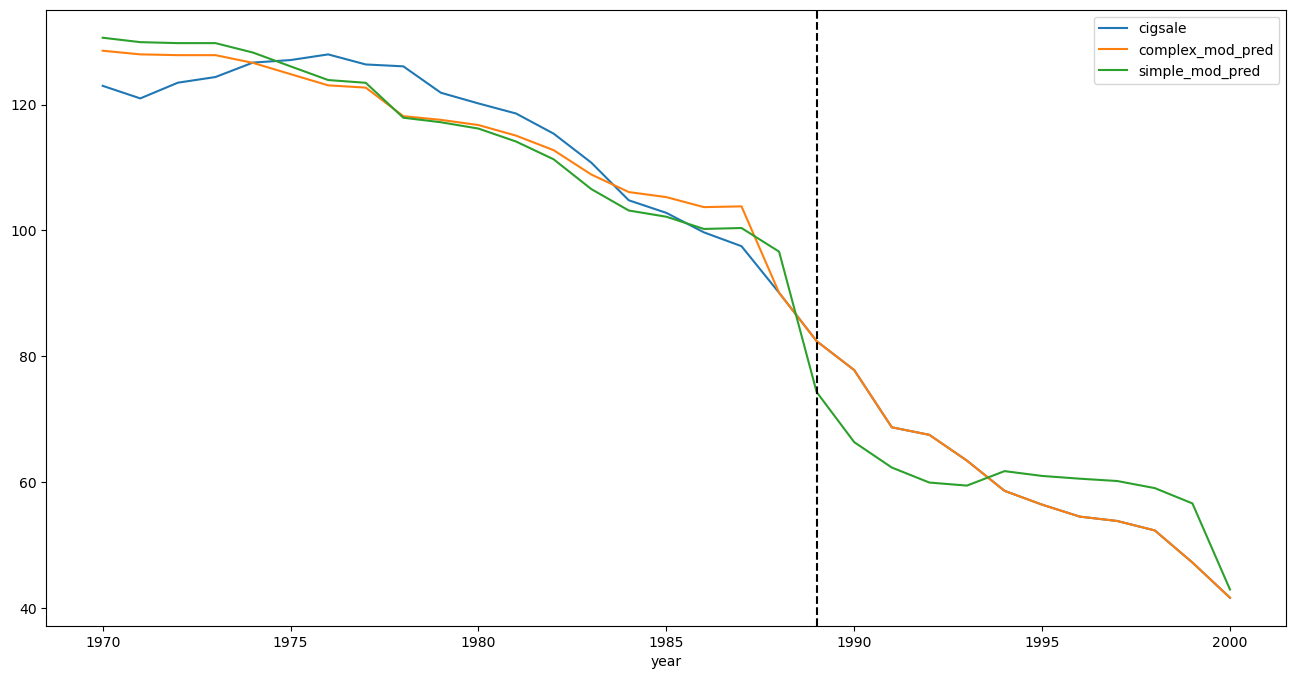

In [159]:
df.set_index("year")[['cigsale', 'complex_mod_pred','simple_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

This model is overfit, especially if you lookt at the prediction for the post treatment intervention. It's a perfect fit! 

You can see this in the prediction - actual plots as well, with that left tail now being a straight line. If I added the pre- excise tax dummy variables this model would probably have an $R^2$ of $1$.

<AxesSubplot: xlabel='cigsale', ylabel='complex_mod_pred'>

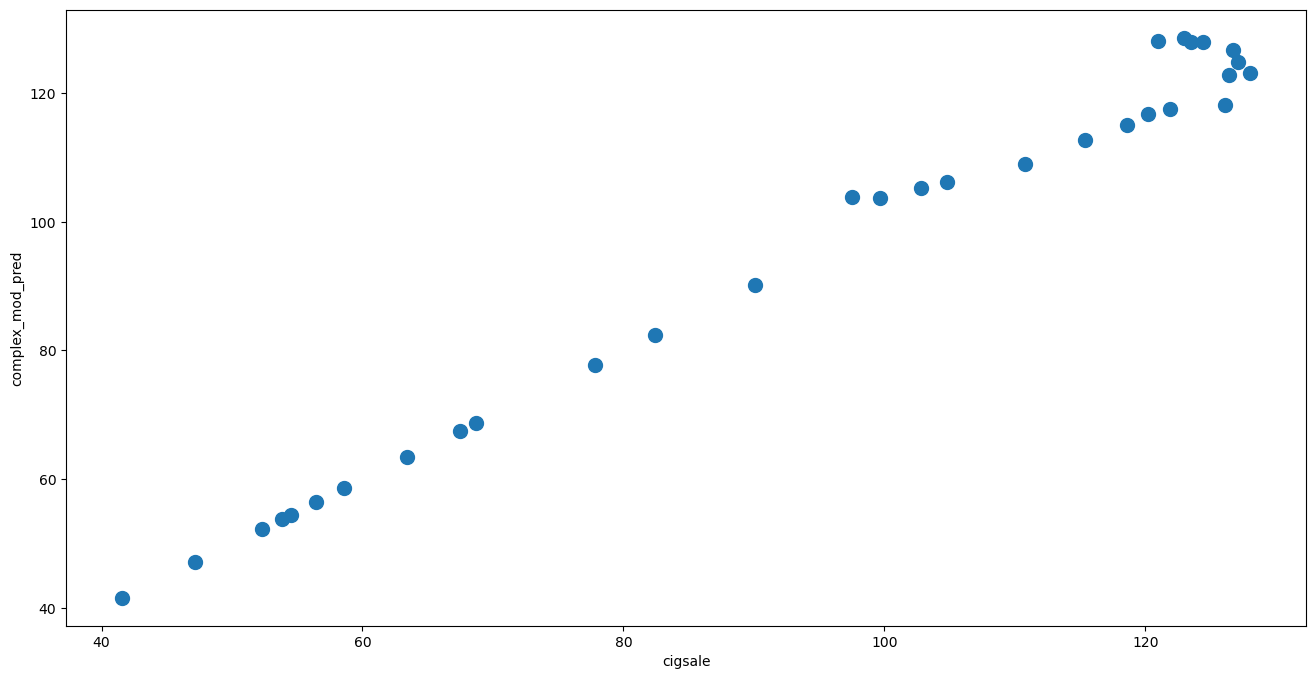

In [160]:
df.plot.scatter(x = 'cigsale', y = 'complex_mod_pred', s=100)

This might seem like a good thing but it's actually a real problem. Say we try to generalise this effect to another scenario. What do you think might happen? 

Well by way of example, let's use this model to see what might happen in another state if they were to introduce a similar increase in the excise tax.

In [161]:
df_new = pd.read_csv("https://raw.githubusercontent.com/Michael-Morgan-Giles/python-causality-handbook/refs/heads/master/causal-inference-for-the-brave-and-true/data/smoking.csv")

# filter for not caligornita
df_new = df_new[df_new['state'] == 36]

# add binary variable for excise tax intro
df_new['excise_tax_intro'] = np.where(df_new['after_treatment'] == True,1,0)

df_new = df_new[['year', 'cigsale','retprice','excise_tax_intro']]

# create log variables for elasticity estimates:
for x in ['cigsale','retprice']:
    df_new[f"ln_{x}"] = np.log(df_new[x])

# dummies
df_new = pd.concat([df_new,pd.get_dummies(df_new['year']).astype(int)], axis = 1)

# print info
df_new.info()

<class 'pandas.core.frame.DataFrame'>
Index: 31 entries, 1085 to 1115
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              31 non-null     int64  
 1   cigsale           31 non-null     float64
 2   retprice          31 non-null     float64
 3   excise_tax_intro  31 non-null     int64  
 4   ln_cigsale        31 non-null     float64
 5   ln_retprice       31 non-null     float64
 6   1970              31 non-null     int64  
 7   1971              31 non-null     int64  
 8   1972              31 non-null     int64  
 9   1973              31 non-null     int64  
 10  1974              31 non-null     int64  
 11  1975              31 non-null     int64  
 12  1976              31 non-null     int64  
 13  1977              31 non-null     int64  
 14  1978              31 non-null     int64  
 15  1979              31 non-null     int64  
 16  1980              31 non-null     int64  
 17 

In [162]:
df_new['new_state_mod_pred'] =  sm.OLS(df['cigsale'], 
             sm.add_constant(df[['excise_tax_intro', 
                                 "ln_retprice"] + df.columns[26:38].tolist()
                               ])).fit().predict(sm.add_constant(df_new[['excise_tax_intro',
                                                                         "ln_retprice"] + df_new.columns[25:37].tolist()]))

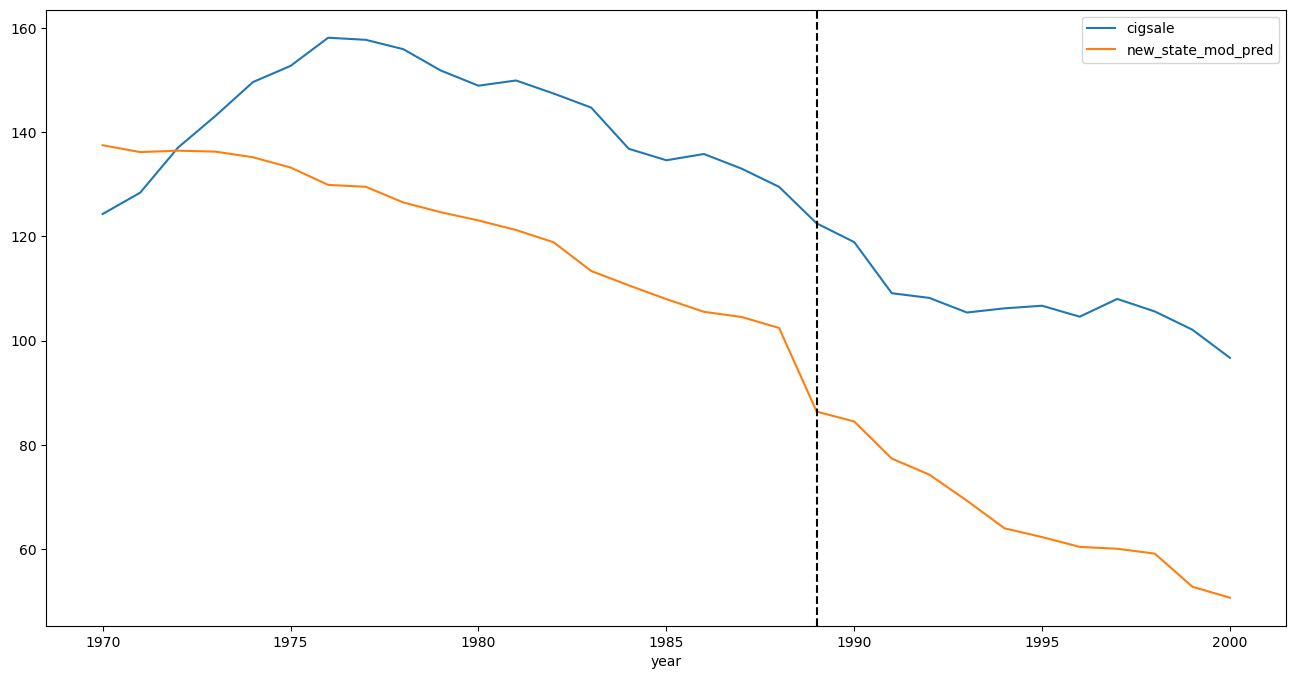

In [163]:
df_new.set_index("year")[['cigsale', 'new_state_mod_pred']].plot()
plt.axvline(x = 1989, color = "black", linestyle = "--")

As you can see, the model is basically entirely incorrect in its prediction. 

The model is "overfit" to the specific example in california and hence isn't very generalisable to other scenarios (the difference between internal vs external validity). 

To get a true causal effect we're going to need a bit more robust approach. We will return to this exactly example when we look at difference-in-differences (DiD).